# Obesity Prediction Project

This notebook was developed as part of an Artificial Intelligence university workshop. Its goal is to predict the obesity level based on personal, dietary, and lifestyle data. In addition, we explore how factors such as the frequency of high-calorie food intake, physical activity, and calorie monitoring (as well as vegetable consumption and water intake) can predict the obesity level of an individual.

We will:
1. Formulate hypotheses on how eating habits and physical activity affect obesity levels.
2. Perform an exploratory data analysis (EDA) with histograms, bar charts, and scatter plots to observe variable distributions, outliers, and relationships.
3. Preprocess the data (handle missing values, encode categorical variables, normalize the features, and apply SMOTE to balance classes).
4. Train different models: Logistic Regression, Linear Regression, and Support Vector Machines (SVM) using cross-validation and grid search to optimize parameters.
5. Evaluate the models using metrics such as Accuracy, Precision, Mean Squared Error (MSE), Mean Absolute Error (MAE), and visualize performance with scatter plots and a confusion matrix.
6. Document all results and analyses in this notebook.


## 1. Data Loading and Exploratory Data Analysis (EDA)

In [19]:
# Import libraries
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (adjust the path if necessary)
data_path = "ObesityDataSet.csv"
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Total records:", len(df))
df.head()

Dataset loaded successfully!
Total records: 2111


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Exploratory Data Analysis

Let's examine basic information, statistics, and distributions to understand the data and formulate hypotheses. For example, we might hypothesize that higher consumption of high-calorie foods is directly correlated with higher obesity levels.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

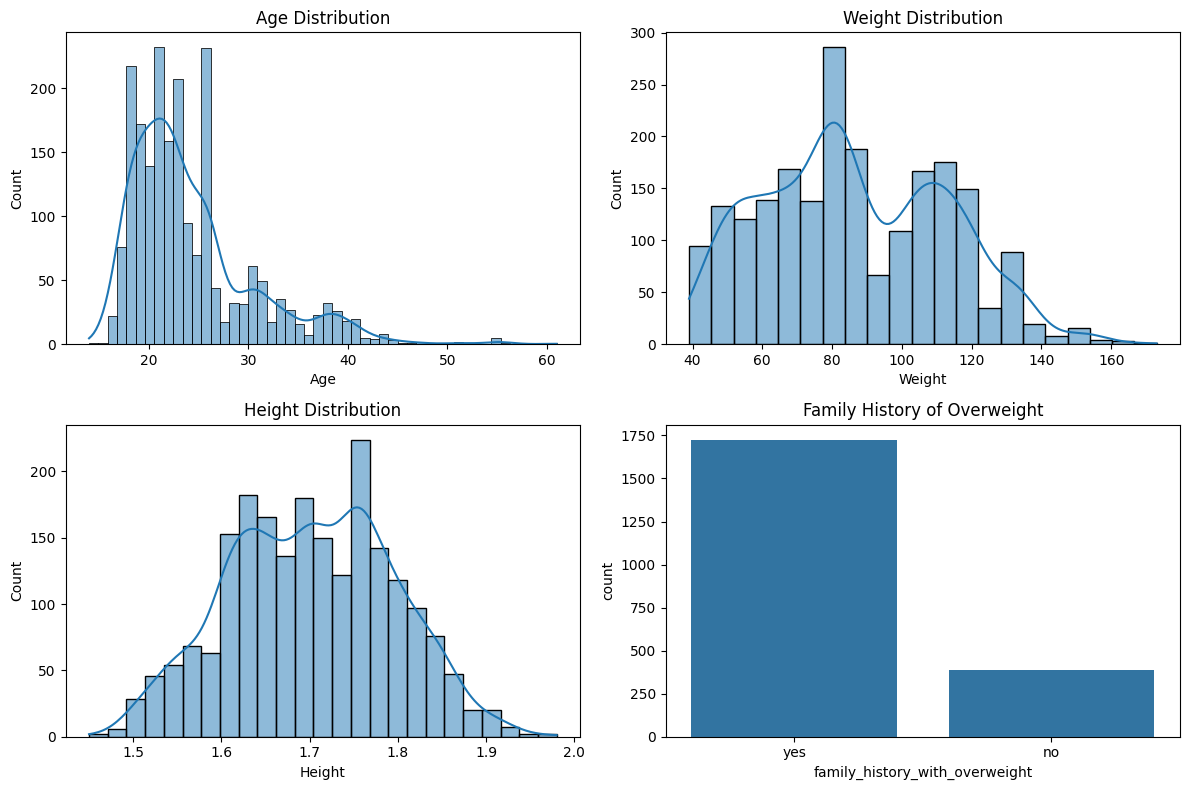

In [5]:
# Basic info and descriptive statistics
df.info()
df.describe()

# Plot distributions for selected variables
fig, axs = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['Age'], kde=True, ax=axs[0,0]).set_title("Age Distribution")
sns.histplot(df['Weight'], kde=True, ax=axs[0,1]).set_title("Weight Distribution")
sns.histplot(df['Height'], kde=True, ax=axs[1,0]).set_title("Height Distribution")
sns.countplot(x='family_history_with_overweight', data=df, ax=axs[1,1]).set_title("Family History of Overweight")
plt.tight_layout()
plt.show()


## 2. Data Preprocessing

In this section, we will:
- Impute missing numeric values using the mean.
- Fill any remaining missing values in categorical fields with a placeholder and encode them using One-Hot Encoding.
- Normalize the features.
- Convert the target variable (assumed to be `NObeyesdad`) to numeric labels.

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Assume the target variable is 'NObeyesdad'; map its labels to numeric codes (adjust mapping as needed)
target_mapping = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}

if 'NObeyesdad' in df.columns:
    df['NObeyesdad'] = df['NObeyesdad'].map(target_mapping)

# Separate features and target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# Impute missing numeric values with the mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

# Fill missing categorical values and apply One-Hot Encoding
categorical_cols = X.select_dtypes(include=["object"]).columns
X[categorical_cols] = X[categorical_cols].fillna("missing")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Data preprocessing completed!")
print("Total records after preprocessing:", len(X_scaled))

Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
Data preprocessing completed!
Total records after preprocessing: 2111


## 3. Addressing Class Imbalance using SMOTE

Since the dataset is imbalanced, we will use SMOTE (Synthetic Minority Over-sampling Technique) to balance the classes.

In [7]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print("After SMOTE, dataset shape:", X_res.shape)
print("Class distribution after SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE, dataset shape: (2457, 23)
Class distribution after SMOTE:
NObeyesdad
1    351
2    351
3    351
4    351
0    351
5    351
6    351
Name: count, dtype: int64


## 4. Data Splitting

We split the balanced dataset into training (70%), testing (25%), and final evaluation (5%) sets.

In [14]:
# First, set aside 5% for final evaluation
X_temp, X_eval, y_temp, y_eval = train_test_split(X_res, y_res, test_size=0.05, random_state=42)

# Then, split the remaining 95% into 70% training and 25% testing
# To get approximately 25% of original data in the test set, use test_size=0.2632 on the remaining portion
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2632, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("Final evaluation set size:", X_eval.shape[0])

Training set size: 1719
Testing set size: 615
Final evaluation set size: 123


## 5. Model Training and Evaluation

We will train and evaluate three models:
- **Logistic Regression** (classification model)
- **Linear Regression** (regression model; predictions will be rounded for classification evaluation)
- **Support Vector Machine (SVM)** (classification model)

We use GridSearchCV for hyperparameter tuning and cross-validation.

### 5.1 Logistic Regression

In [21]:
# Initialize logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Parameter grid
param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

grid_log = GridSearchCV(log_reg, param_grid_log, cv=5, scoring='accuracy')
grid_log.fit(X_train, y_train)

print("Best parameters for Logistic Regression:", grid_log.best_params_)
print("Best cross-validation accuracy:", grid_log.best_score_)

# Evaluate on test set
y_pred_log = grid_log.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
print("\nLogistic Regression Evaluation (Test Set):")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2'}
Best cross-validation accuracy: 0.9389297579496916

Logistic Regression Evaluation (Test Set):
Accuracy: 0.9658536585365853
Precision: 0.9662929044919603
Confusion Matrix:
 [[91  2  0  0  0  0  0]
 [ 3 76  2  1  0  0  0]
 [ 0  1 78  1  0  0  0]
 [ 0  0  5 86  1  0  0]
 [ 0  0  0  2 73  0  0]
 [ 0  0  0  0  2 97  0]
 [ 0  0  0  0  0  1 93]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        93
           1       0.96      0.93      0.94        82
           2       0.92      0.97      0.95        80
           3       0.96      0.93      0.95        92
           4       0.96      0.97      0.97        75
           5       0.99      0.98      0.98        99
           6       1.00      0.99      0.99        94

    accuracy                           0.97       615
   macro avg       0.96      0.97      0.96       615
weighted avg       0.97      0.97      0.97     

### 5.2 Linear Regression

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

# Train linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on test set and round predictions
y_pred_lin = np.round(lin_reg.predict(X_test)).astype(int)
y_pred_lin = np.clip(y_pred_lin, y_train.min(), y_train.max())

print("\nLinear Regression Evaluation (Test Set):")
mse_lin = mean_squared_error(y_test, lin_reg.predict(X_test))
mae_lin = mean_absolute_error(y_test, lin_reg.predict(X_test))
r2_lin = r2_score(y_test, lin_reg.predict(X_test))
print("MSE:", mse_lin)
print("MAE:", mae_lin)
print("R² Score:", r2_lin)

print("Accuracy:", accuracy_score(y_test, y_pred_lin))
print("Precision:", precision_score(y_test, y_pred_lin, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lin))
print(classification_report(y_test, y_pred_lin))


Linear Regression Evaluation (Test Set):
MSE: 0.18412203075933062
MAE: 0.31956736996992197
R² Score: 0.9557733457868522
Accuracy: 0.8601626016260162
Precision: 0.8800253503016243
Confusion Matrix:
 [[89  4  0  0  0  0  0]
 [ 4 53 25  0  0  0  0]
 [ 0  0 73  7  0  0  0]
 [ 0  0  6 85  1  0  0]
 [ 0  0  0  8 67  0  0]
 [ 0  0  0  0  1 97  1]
 [ 0  0  0  0  0 29 65]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        93
           1       0.93      0.65      0.76        82
           2       0.70      0.91      0.79        80
           3       0.85      0.92      0.89        92
           4       0.97      0.89      0.93        75
           5       0.77      0.98      0.86        99
           6       0.98      0.69      0.81        94

    accuracy                           0.86       615
   macro avg       0.88      0.86      0.86       615
weighted avg       0.88      0.86      0.86       615



### 5.3 Support Vector Machine (SVM)

In [22]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best parameters for SVM:", grid_svm.best_params_)
print("Best cross-validation accuracy:", grid_svm.best_score_)

y_pred_svm = grid_svm.predict(X_test)
print("\nSVM Evaluation (Test Set):")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Best parameters for SVM: {'C': 10, 'kernel': 'linear'}
Best cross-validation accuracy: 0.9610346464167062

SVM Evaluation (Test Set):
Accuracy: 0.9707317073170731
Precision: 0.9711588359746116
Confusion Matrix:
 [[91  2  0  0  0  0  0]
 [ 3 76  3  0  0  0  0]
 [ 0  0 77  3  0  0  0]
 [ 0  0  4 88  0  0  0]
 [ 0  0  0  1 74  0  0]
 [ 0  0  0  0  1 98  0]
 [ 0  0  0  0  0  1 93]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        93
           1       0.97      0.93      0.95        82
           2       0.92      0.96      0.94        80
           3       0.96      0.96      0.96        92
           4       0.99      0.99      0.99        75
           5       0.99      0.99      0.99        99
           6       1.00      0.99      0.99        94

    accuracy                           0.97       615
   macro avg       0.97      0.97      0.97       615
weighted avg       0.97      0.97      0.97       615



## 6. Visualizing Model Performance

Below we visualize the regression results for the Linear Regression model by plotting Actual vs. Predicted values.

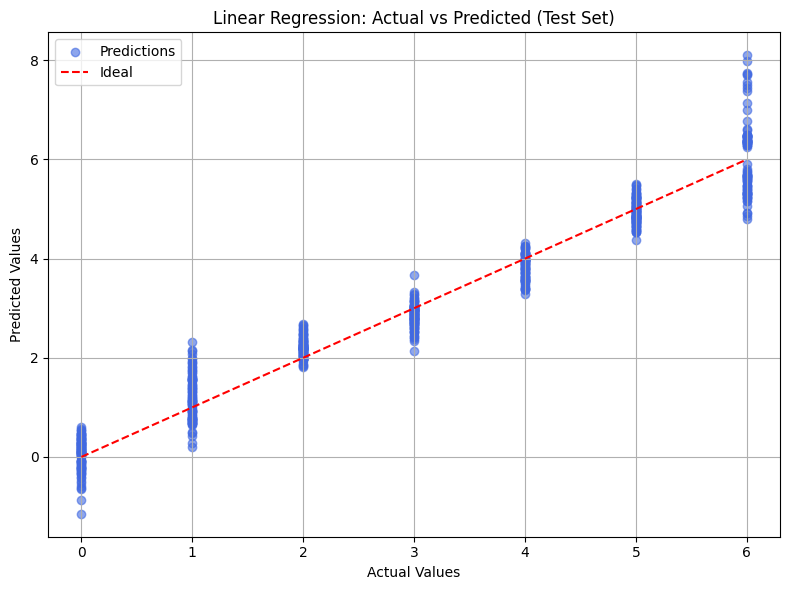

In [23]:
def plot_regression_results(y_true, y_pred, title="Regression Results"):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, color='royalblue', label="Predictions")
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Ideal")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

y_pred_lin_cont = lin_reg.predict(X_test)  # Continuous predictions for visualization
plot_regression_results(y_test, y_pred_lin_cont, title="Linear Regression: Actual vs Predicted (Test Set)")

## 7. Conclusion

In this notebook, we:
- Formulated hypotheses regarding the influence of dietary habits and physical activity on obesity levels.
- Performed exploratory data analysis to understand the data distribution and relationships.
- Preprocessed the data, handled missing values, encoded categorical features, normalized, and applied SMOTE to balance the classes.
- Trained three models: Logistic Regression, Linear Regression, and SVM, tuning parameters via GridSearchCV.
- Evaluated the models using accuracy, precision, RMSE, MAE, R², and confusion matrices.
- Visualized the regression results with a scatter plot comparing actual vs. predicted values.

Overall, the results indicate that the models can predict obesity levels reasonably well, and the feature impact analysis provides insights into which factors are most influential.

Further work could include additional feature engineering and fine-tuning of model parameters.